In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet50
import numpy as np
import matplotlib.pyplot as plt
from time import time

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Data transforms & loaders

train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

batch_size = 128
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

100%|██████████| 169M/169M [00:02<00:00, 81.1MB/s] 


In [5]:
# CutMix Function

def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)   
    cut_h = int(H * cut_rat)   

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size()[0]).to(device)
    y_a = y
    y_b = y[rand_index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))
    return x, y_a, y_b, lam

In [8]:
# ResNet-50

model = resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 100)

# Multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


In [9]:
# Loss and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [10]:
# Training & Validation

def train(epoch, print_every=50):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    start_time = time()

    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)

        apply_cutmix = np.random.rand() < 0.5
        if apply_cutmix:
            inputs, targets_a, targets_b, lam = cutmix_data(inputs, targets)
            outputs = model(inputs)
            loss = lam*criterion(outputs, targets_a) + (1-lam)*criterion(outputs, targets_b)
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)

        if apply_cutmix:
            correct += (lam*predicted.eq(targets_a).sum().item() +
                        (1-lam)*predicted.eq(targets_b).sum().item())
        else:
            correct += predicted.eq(targets).sum().item()

        total += targets.size(0)

        if (batch_idx+1) % print_every == 0:
            print(f"[Epoch {epoch} | Batch {batch_idx+1}/{len(trainloader)}] "
                  f"Loss: {running_loss/(batch_idx+1):.4f} | Acc: {100.*correct/total:.2f}% | "
                  f"LR: {scheduler.get_last_lr()[0]:.6f}")

    duration = time() - start_time
    acc = 100.*correct/total
    print(f"Epoch {epoch} DONE in {duration:.1f}s | Train Loss: {running_loss/len(trainloader):.4f} | Train Acc: {acc:.2f}%")
    return acc

def test(epoch):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    start_time = time()

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)

    duration = time() - start_time
    acc = 100.*correct/total
    print(f"Epoch {epoch} TEST DONE in {duration:.1f}s | Test Loss: {test_loss/len(testloader):.4f} | Test Acc: {acc:.2f}%")
    return acc

In [11]:
num_epochs = 50
best_acc = 0
train_acc_history, test_acc_history = [], []

for epoch in range(1, num_epochs+1):
    train_acc = train(epoch, print_every=50)
    test_acc = test(epoch)
    scheduler.step()

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    if test_acc > best_acc:
        print(f"🔥 Saving new best model (Acc: {test_acc:.2f}%)...\n")
        torch.save(model.state_dict(), "ResNet-50.pth")
        best_acc = test_acc
    print("="*70)

[Epoch 1 | Batch 50/391] Loss: 4.0613 | Acc: 12.33% | LR: 0.010000
[Epoch 1 | Batch 100/391] Loss: 3.1940 | Acc: 28.23% | LR: 0.010000
[Epoch 1 | Batch 150/391] Loss: 2.7518 | Acc: 36.54% | LR: 0.010000
[Epoch 1 | Batch 200/391] Loss: 2.4935 | Acc: 41.69% | LR: 0.010000
[Epoch 1 | Batch 250/391] Loss: 2.3218 | Acc: 45.30% | LR: 0.010000
[Epoch 1 | Batch 300/391] Loss: 2.2014 | Acc: 47.86% | LR: 0.010000
[Epoch 1 | Batch 350/391] Loss: 2.1390 | Acc: 49.16% | LR: 0.010000
Epoch 1 DONE in 305.4s | Train Loss: 2.0703 | Train Acc: 50.67%
Epoch 1 TEST DONE in 22.8s | Test Loss: 0.9369 | Test Acc: 73.15%
🔥 Saving new best model (Acc: 73.15%)...

[Epoch 2 | Batch 50/391] Loss: 1.4419 | Acc: 66.16% | LR: 0.009973
[Epoch 2 | Batch 100/391] Loss: 1.5693 | Acc: 62.88% | LR: 0.009973
[Epoch 2 | Batch 150/391] Loss: 1.5224 | Acc: 63.46% | LR: 0.009973
[Epoch 2 | Batch 200/391] Loss: 1.4617 | Acc: 64.75% | LR: 0.009973
[Epoch 2 | Batch 250/391] Loss: 1.4848 | Acc: 64.03% | LR: 0.009973
[Epoch 2 | Bat

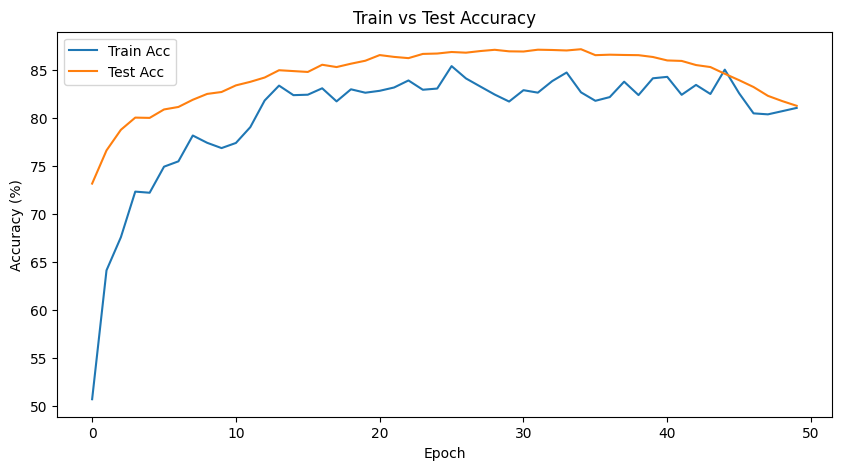

In [ ]:
# Accuracy Plot

plt.figure(figsize=(10,5))
plt.plot(train_acc_history, label="Train Acc")
plt.plot(test_acc_history, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.savefig("accuracy_plot.png")   
plt.show()